# Figure 5 — Supplementary Bayesian regression, independent per storm (Path A)

**Why this notebook exists.** The hierarchical version (`figure5_supp_bayesian_hierarchical.ipynb`) revealed a fundamental identifiability problem: with J = 2 hurricane groups, the random-effect dispersion σ_k cannot be estimated from data — the σ_k posterior just inherits the prior. When the prior is loose, the sampler diverges; when the prior is tight, partial pooling becomes too aggressive and over-shrinks Milton's slopes toward Helene's, producing artefactual cross-storm agreement.

**The right framework for J = 2 is independent per-storm Bayesian regression.** Each storm gets its own regression with weakly informative priors on the coefficients; the priors regularise Milton's n = 21 thin fit without forcing Milton's slopes toward Helene's.

This is path **A** from the figure5 discussion. It complements:
- `figure5_socioeconomic_drivers.ipynb` → main figure (pooled OLS panel a + recovery descriptive + income paradox; per-storm OLS in supplement S1)
- `figure5_supp_bayesian_hierarchical.ipynb` → the hierarchical attempt, kept for transparency; demoted to "robustness check showing why hierarchical doesn't work at J = 2"
- This notebook → the practical Bayesian alternative we should actually report per storm

## Model

For each storm h ∈ {Helene, Milton} and each DV y separately:

$$y_i = \alpha + \sum_k \beta_k \cdot x_{ik} + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma_y)$$

**Priors** (Gelman-style "weakly informative", scaled to the DV's standard deviation):

$$\alpha \sim \mathcal{N}(0, 10 \sigma_y), \quad \beta_k \sim \mathcal{N}(0, 2.5 \sigma_y), \quad \sigma_y \sim \text{HalfNormal}(0, \sigma_y^\text{pooled})$$

where σ_y is the pooled-sample standard deviation of the DV. For the three DVs:

| DV | sd_y (pooled) | Slope prior |
|---|---:|---|
| Largest Drop — Within (%) | 10.4 | `Normal(0, 26)` |
| Largest Drop — Inflow (%) | 15.5 | `Normal(0, 39)` |
| Outflow Increase (%) | 32.1 | `Normal(0, 80)` |

## Predictor set (v3 — aligned with figure5 supplement S1)

**Ten predictors** are fitted, matching `figure5_socioeconomic_drivers.ipynb` supplement S1's `PER_HURRICANE_FEATURES`:

| Continuous (z-scored) | Binary |
|---|---|
| `median_household_income`, `pct_no_vehicle`, `pct_white`, `nchs_code`, `total_population`, `pop_density`, `dist_to_track_mi`, `insurance_coverage_pct`, `precip_total_7day` | `is_coastal` |

**Six predictors are displayed** in the forest plots (matching figure5 main panel a's `PREDICTOR_ORDER` minus `is_milton`):

`dist_to_track_mi`, `precip_total_7day`, `median_household_income`, `insurance_coverage_pct`, `pct_white`, `is_coastal`

The remaining four (`pct_no_vehicle`, `nchs_code`, `total_population`, `pop_density`) are *nuisance controls* — fitted to absorb confounding variance but not highlighted.

**Why this matters**: with Milton's n = 21, dropping the nuisance controls from the model creates omitted-variable bias that can *flip the sign* of substantive coefficients. The most dramatic case: `median_household_income` on `Outflow Increase` is `+9.68` with 6 predictors (matching this notebook's v1/v2 fit) but `−16.31` with 10 predictors (matching the figure5 S1 OLS and the "income paradox" framing). v3 fixes this by using the same 10-predictor spec everywhere.

## Three DVs

`largest_drop_within`, `largest_drop_inflow`, `largest_increase_outflow` (matching figure5 panel a after recovery was demoted to panel b).

So **six models total** (3 DVs × 2 storms), each fit independently.

## What the figures show

| Figure | Layout | Purpose |
|---|---|---|
| **per-storm forest** | 2 rows × 3 DVs | Same visual as supplement S1 (OLS) — but with proper Bayesian regularisation and no cross-storm shrinkage. Displays the 6 highlighted predictors. |
| **overlay** | 1 row × 3 DVs | Helene & Milton posteriors on the same axes per predictor — the cleanest visualisation of "do the two storms agree?" |
| **vs OLS** | 2 rows × 3 DVs | Per-storm OLS (10-predictor, matches S1) overlaid with per-storm Bayesian posterior, to show where the priors shrink Milton's n = 21 estimates |

**Version history**
- **v1**: `Normal(0, 1)` priors → prior dominated, all posteriors crushed to ~0 ± 1
- **v2**: `Normal(0, 2.5 σ_y)` priors (Gelman default) → posteriors recovered, but only 6 predictors → OLS didn't match S1
- **v3 (current)**: same priors as v2, **but full 10-predictor model** → OLS now matches S1 exactly

**Output files** (in `results/npj_figures/`):
- `figure5_supp_bayesian_indep_per_storm.{pdf,png}`
- `figure5_supp_bayesian_indep_overlay.{pdf,png}`
- `figure5_supp_bayesian_indep_vs_ols.{pdf,png}`

## Installation

Same dependencies as the hierarchical notebook: `pymc`, `bambi`, `arviz`.

**With pip:**
```bash
pip install pymc bambi arviz
```

**With conda:**
```bash
conda install -c conda-forge pymc bambi arviz
```

**Sampling time**: ~10–20 seconds per model (no hierarchy → simpler geometry). 6 models total in roughly 1–2 minutes.


In [1]:
import sys

REQUIRED = ['pymc', 'bambi', 'arviz']
missing = []
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f'Missing packages: {missing}')
    print(f'\nInstall with:')
    print(f'  {sys.executable} -m pip install {" ".join(missing)}')
    print(f'\nThen restart the kernel and re-run from the top.')
    raise ImportError(f'Install missing packages: {missing}')

import pymc, bambi, arviz
print(f'  python : {sys.executable}')
print(f'  pymc   : {pymc.__version__}')
print(f'  bambi  : {bambi.__version__}')
print(f'  arviz  : {arviz.__version__}')


  python : /Users/qing/miniconda3/envs/geo_env/bin/python
  pymc   : 5.28.5
  bambi  : 0.17.2
  arviz  : 0.23.4


In [2]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import bambi as bmb
import arviz as az
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# npj Urban Sustainability print-ready style (matches figure5)
mpl.rcParams.update({
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size'         : 8,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 8,
    'xtick.labelsize'   : 7,
    'ytick.labelsize'   : 7,
    'legend.fontsize'   : 7,
    'axes.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
})


In [3]:
# Project path resolution
def find_project_root(start: pathlib.Path) -> pathlib.Path:
    sentinel = pathlib.Path('results') / 'local_level' / 'regression' / 'pooled_dataset_with_precip.csv'
    for p in [start, *start.parents]:
        if (p / sentinel).exists():
            return p
    raise FileNotFoundError(f'Cannot find {sentinel} starting from {start}')

PROJECT_ROOT = find_project_root(pathlib.Path.cwd())
RESULTS = PROJECT_ROOT / 'results'
OUT_DIR = RESULTS / 'npj_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

POOL = pd.read_csv(RESULTS / 'local_level' / 'regression' / 'pooled_dataset_with_precip.csv')

DV_TO_COL = {
    'Largest Drop — Within (%)': 'largest_drop_within',
    'Largest Drop — Inflow (%)': 'largest_drop_inflow',
    'Outflow Increase (%)'           : 'largest_increase_outflow',
}
DV_ORDER = list(DV_TO_COL.keys())
DV_SHORT = {
    'Largest Drop — Within (%)': 'Largest drop (within)',
    'Largest Drop — Inflow (%)': 'Largest drop (inflow)',
    'Outflow Increase (%)'           : 'Outflow surge',
}

# ── PREDICTOR-SET ALIGNMENT FIX (v3) ──────────────────────────────────────────
# v1/v2 used only 6 "interesting" predictors. The user noticed OLS coefficients
# disagreed with figure5_socioeconomic_drivers.ipynb's supplement S1, which uses
# 10 predictors per storm. Verified mismatch (most striking case):
#   Milton x Outflow surge x median_household_income
#     6-pred per-storm OLS:  +9.68   (sign flipped!)
#     10-pred per-storm OLS: -16.31  (the "income paradox" coefficient)
# Cause: omitted-variable bias at Milton n = 21 when pop_density, total_population,
# nchs_code, pct_no_vehicle are dropped from the model.
# v3 uses the *same* 10-predictor spec as S1 (PER_HURRICANE_FEATURES), then displays
# only the 6 highlighted predictors in forest plots — same hidden-vs-displayed
# pattern that figure5 main panel a uses.

# All 9 continuous predictors get z-scored (matches figure5 panel a / S1).
CONTINUOUS = [
    'median_household_income',
    'pct_no_vehicle',
    'pct_white',
    'nchs_code',
    'total_population',
    'pop_density',
    'dist_to_track_mi',
    'insurance_coverage_pct',
    'precip_total_7day',
]
BINARY = ['is_coastal']
# Full model spec (10 predictors) — matches S1's PER_HURRICANE_FEATURES exactly
MODEL_FEATURES = CONTINUOUS + BINARY
# Subset displayed in the forest plots — matches figure5 panel a's PREDICTOR_ORDER
# minus is_milton (which is constant within each per-storm fit so it's irrelevant here)
DISPLAY_PREDICTORS = [
    'dist_to_track_mi',
    'precip_total_7day',
    'median_household_income',
    'insurance_coverage_pct',
    'pct_white',
    'is_coastal',
]
# Back-compat alias (older variable name used in earlier draft cells)
PREDICTORS = MODEL_FEATURES

PREDICTOR_LABEL = {
    'median_household_income': 'Median income',
    'pct_no_vehicle'         : '% No vehicle',
    'pct_white'              : '% White',
    'nchs_code'              : 'NCHS urban-rural',
    'total_population'       : 'Total population',
    'pop_density'            : 'Population density',
    'dist_to_track_mi'       : 'Distance to track',
    'insurance_coverage_pct' : 'Insurance coverage',
    'precip_total_7day'      : '7-day precipitation',
    'is_coastal'             : 'Coastal county',
}

# Standardise *globally* on the pooled sample so Helene and Milton models share scale.
POOL_Z = POOL.copy()
POOL_Z[CONTINUOUS] = StandardScaler().fit_transform(POOL[CONTINUOUS])

DV_COLOR = {
    'Largest Drop — Within (%)': '#0072B2',
    'Largest Drop — Inflow (%)': '#56B4E9',
    'Outflow Increase (%)'           : '#D55E00',
}
HURR_COLOR = {'helene': '#1f77b4', 'milton': '#d62728'}

def save_panel(fig, stem):
    pdf_path = OUT_DIR / f'{stem}.pdf'
    png_path = OUT_DIR / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'  saved → {pdf_path.relative_to(PROJECT_ROOT)}')
    print(f'  saved → {png_path.relative_to(PROJECT_ROOT)}')

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'OUT_DIR      : {OUT_DIR}')
print(f'POOL_Z n     : {len(POOL_Z)}  (helene={(POOL_Z.hurricane=="helene").sum()}, milton={(POOL_Z.hurricane=="milton").sum()})')
print(f'MODEL_FEATURES ({len(MODEL_FEATURES)}) : {MODEL_FEATURES}')
print(f'DISPLAY        ({len(DISPLAY_PREDICTORS)}) : {DISPLAY_PREDICTORS}')

PROJECT_ROOT : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category
OUT_DIR      : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures
POOL_Z n     : 59  (helene=38, milton=21)
MODEL_FEATURES (10) : ['median_household_income', 'pct_no_vehicle', 'pct_white', 'nchs_code', 'total_population', 'pop_density', 'dist_to_track_mi', 'insurance_coverage_pct', 'precip_total_7day', 'is_coastal']
DISPLAY        (6) : ['dist_to_track_mi', 'precip_total_7day', 'median_household_income', 'insurance_coverage_pct', 'pct_white', 'is_coastal']


In [4]:
# Independent Bayesian fit per (storm, DV). No hierarchy.
# Model is the same 10-predictor spec as figure5 main panel a (per-storm version
# = supplement S1 spec). Weakly informative priors scaled to the DV's sd
# (Gelman / Stan / rstanarm default).

# ── PRIOR-WIDTH FIX (v2) ──────────────────────────────────────────────────────
# v1 used Normal(0, 1) on every slope, which was 26-80x too tight for these DVs
# (raw % scale, sd_y = 10 to 32). v2 uses Gelman's 2.5 * sd_y default.
#
# ── PREDICTOR-SET ALIGNMENT (v3) ──────────────────────────────────────────────
# v1/v2 used only 6 "interesting" predictors. v3 uses the same 10 as S1 so the
# OLS comparison is apples-to-apples with figure5_socioeconomic_drivers.ipynb.

PRIOR_WIDTH_FACTOR = 2.5  # Gelman default for weakly informative regression priors

def make_priors_for_dv(dv_col, df_for_scale):
    """Slope priors Normal(0, k * sd_y); intercept loose; sigma HalfNormal(0, sd_y)."""
    sd_y = df_for_scale[dv_col].std()
    width = PRIOR_WIDTH_FACTOR * sd_y
    priors = {f: bmb.Prior('Normal', mu=0, sigma=width) for f in MODEL_FEATURES}
    priors['Intercept'] = bmb.Prior('Normal', mu=0, sigma=10 * sd_y)
    priors['sigma']     = bmb.Prior('HalfNormal', sigma=sd_y)
    return priors


SAMPLE_KWARGS = dict(
    draws=2000,
    tune=1500,
    chains=4,
    target_accept=0.95,
    random_seed=42,
    progressbar=False,
)

FORMULA_RHS = ' + '.join(MODEL_FEATURES)

# Sanity-print the per-DV prior widths so it's obvious what we're using.
print('Slope-prior widths (Normal(0, sigma) per DV) — scaled by pooled sd_y:')
for dv_lab, dv_col in DV_TO_COL.items():
    sd_y = POOL_Z[dv_col].std()
    print(f'  {dv_lab:32s} sd_y={sd_y:5.2f}  ->  slope prior Normal(0, {PRIOR_WIDTH_FACTOR*sd_y:5.1f})')
print(f'\nFormula RHS: {FORMULA_RHS}\n')

fits = {}   # {(hurricane, dv_lab): {'idata': ..., 'model': ...}}
for hkey in ['helene', 'milton']:
    sub = POOL_Z[POOL_Z['hurricane'] == hkey].copy()
    for dv_lab, dv_col in DV_TO_COL.items():
        formula = f'{dv_col} ~ {FORMULA_RHS}'
        print(f'-- Fitting: {hkey:6s}  {dv_lab}  (n={len(sub)}, {len(MODEL_FEATURES)} predictors) --')
        priors = make_priors_for_dv(dv_col, POOL_Z)
        model = bmb.Model(formula, sub, family='gaussian', priors=priors)
        idata = model.fit(**SAMPLE_KWARGS)
        fits[(hkey, dv_lab)] = {'model': model, 'idata': idata, 'n': len(sub)}
        print(f'   done.\n')

Slope-prior widths (Normal(0, sigma) per DV) — scaled by pooled sd_y:
  Largest Drop — Within (%)        sd_y=10.42  ->  slope prior Normal(0,  26.1)
  Largest Drop — Inflow (%)        sd_y=15.48  ->  slope prior Normal(0,  38.7)
  Outflow Increase (%)             sd_y=32.13  ->  slope prior Normal(0,  80.3)

Formula RHS: median_household_income + pct_no_vehicle + pct_white + nchs_code + total_population + pop_density + dist_to_track_mi + insurance_coverage_pct + precip_total_7day + is_coastal

-- Fitting: helene  Largest Drop — Within (%)  (n=38, 10 predictors) --


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, median_household_income, pct_no_vehicle, pct_white, nchs_code, total_population, pop_density, dist_to_track_mi, insurance_coverage_pct, precip_total_7day, is_coastal]
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...


   done.

-- Fitting: helene  Largest Drop — Inflow (%)  (n=38, 10 predictors) --


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, median_household_income, pct_no_vehicle, pct_white, nchs_code, total_population, pop_density, dist_to_track_mi, insurance_coverage_pct, precip_total_7day, is_coastal]
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 2 seconds.


   done.

-- Fitting: helene  Outflow Increase (%)  (n=38, 10 predictors) --


...

   done.

-- Fitting: milton  Largest Drop — Inflow (%)  (n=21, 10 predictors) --


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, median_household_income, pct_no_vehicle, pct_white, nchs_code, total_population, pop_density, dist_to_track_mi, insurance_coverage_pct, precip_total_7day, is_coastal]
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 3 seconds.
Initializing NUTS using jitter+adapt_diag...


   done.

-- Fitting: milton  Outflow Increase (%)  (n=21, 10 predictors) --


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, median_household_income, pct_no_vehicle, pct_white, nchs_code, total_population, pop_density, dist_to_track_mi, insurance_coverage_pct, precip_total_7day, is_coastal]
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 3 seconds.


   done.



In [5]:
print('=== MCMC diagnostics (6 fits total) ===')
print(f'\n{"hurricane":<10} {"DV":<28} {"R-hat":>6} {"ESS":>6} {"div":>4}')
print('-' * 60)
for (hkey, dv_lab), d in fits.items():
    idata = d['idata']
    rh = float(az.rhat(idata).to_array().max())
    ess = float(az.ess(idata).to_array().min())
    div = int(idata.sample_stats['diverging'].sum().values)
    rh_flag = ' ' if rh <= 1.01 else '!'
    ess_flag = ' ' if ess >= 400 else '!'
    div_flag = ' ' if div == 0 else '!'
    print(f'{hkey:<10} {dv_lab:<28} {rh:>6.3f}{rh_flag} {ess:>6.0f}{ess_flag} {div:>4d}{div_flag}')


=== MCMC diagnostics (6 fits total) ===

hurricane  DV                            R-hat    ESS  div
------------------------------------------------------------
helene     Largest Drop — Within (%)     1.002    3616     0 
helene     Largest Drop — Inflow (%)     1.001    3667     0 
helene     Outflow Increase (%)          1.001    3706     0 
milton     Largest Drop — Within (%)     1.002    2753     0 
milton     Largest Drop — Inflow (%)     1.001    2846     0 
milton     Outflow Increase (%)          1.002    2868     0 


In [6]:
# Posterior summaries: posterior mean + 95% HDI per (storm, DV, predictor).
# Returns the full 10-predictor summary; the plotting cells then slice to DISPLAY_PREDICTORS.

def get_summary(hkey, dv_lab):
    idata = fits[(hkey, dv_lab)]['idata']
    return az.summary(idata, var_names=MODEL_FEATURES, hdi_prob=0.95)

# Sanity check: print one full summary
print('=== Example posterior summary (Helene, Outflow surge) — all 10 predictors ===')
print(get_summary('helene', 'Outflow Increase (%)').round(2))

=== Example posterior summary (Helene, Outflow surge) — all 10 predictors ===
                          mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  \
median_household_income  19.26   5.70      7.71      30.04       0.07   
pct_no_vehicle            9.30   4.84     -0.03      19.19       0.07   
pct_white                 2.29   4.72     -7.03      11.58       0.06   
nchs_code                 3.65  14.61    -24.73      32.47       0.24   
total_population         -1.66   6.08    -13.68      10.16       0.09   
pop_density              -9.17  15.47    -41.04      20.34       0.24   
dist_to_track_mi        -12.03   4.46    -20.75      -3.25       0.05   
insurance_coverage_pct   -1.94   4.07     -9.79       6.02       0.05   
precip_total_7day       -14.39   7.88    -28.92       1.95       0.09   
is_coastal               27.32  15.32     -3.77      56.22       0.17   

                         mcse_sd  ess_bulk  ess_tail  r_hat  
median_household_income     0.07    5964.0    5566.0    

## Per-storm forest plot (2 rows × 3 DVs)

Same layout as the OLS supplement S1 and the failed hierarchical S2 per-hurricane forest, but now with **independent** Bayesian posteriors per storm. Milton's posteriors are regularised by the N(0, 1) prior (so they won't be as extreme as raw OLS) but **not** pulled toward Helene's by any hierarchical structure.

Compare with the hierarchical v2 per-hurricane plot to see where partial pooling was distorting things.


  saved → results/npj_figures/figure5_supp_bayesian_indep_per_storm.pdf
  saved → results/npj_figures/figure5_supp_bayesian_indep_per_storm.png


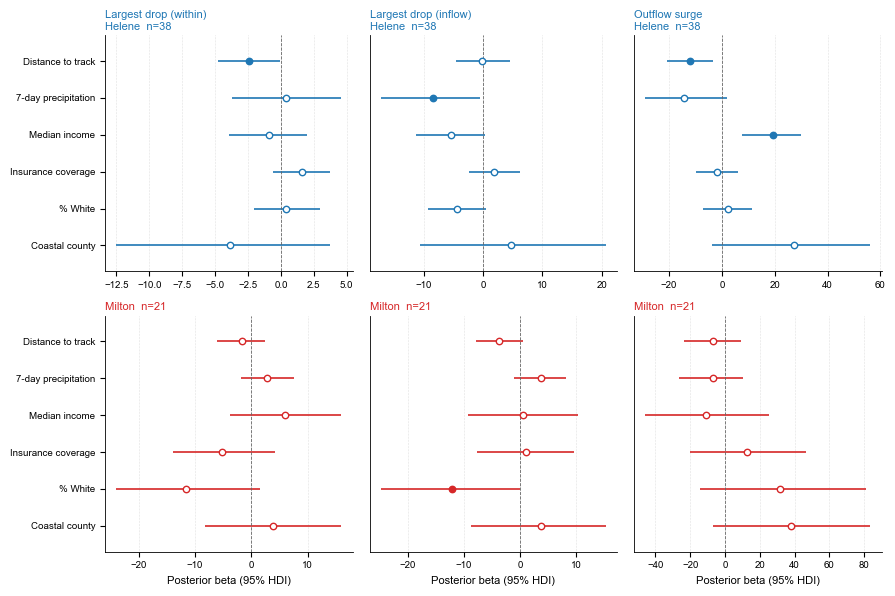

In [7]:
def plot_per_storm_forest():
    fig, axes = plt.subplots(2, 3, figsize=(9.0, 6.0))
    # Iterate over DISPLAY_PREDICTORS only — the other 4 nuisance controls are
    # fitted but not shown (same pattern as figure5 main panel a).
    y_positions = np.arange(len(DISPLAY_PREDICTORS))[::-1]

    for i, hkey in enumerate(['helene', 'milton']):
        for j, dv_lab in enumerate(DV_ORDER):
            ax = axes[i, j]
            summ = get_summary(hkey, dv_lab)
            n = fits[(hkey, dv_lab)]['n']
            color = HURR_COLOR[hkey]

            for k, var in enumerate(DISPLAY_PREDICTORS):
                mean = summ.loc[var, 'mean']
                lo, hi = summ.loc[var, 'hdi_2.5%'], summ.loc[var, 'hdi_97.5%']
                sig = (lo > 0) or (hi < 0)

                ax.hlines(y_positions[k], lo, hi, colors=color, linewidth=1.2)
                ax.plot(mean, y_positions[k], marker='o', markersize=4.6,
                        markerfacecolor=color if sig else 'white',
                        markeredgecolor=color, markeredgewidth=1.0, zorder=3)

            ax.axvline(0, color='#666', linewidth=0.6, linestyle='--')
            ax.set_yticks(y_positions)
            if j == 0:
                ax.set_yticklabels([PREDICTOR_LABEL[v] for v in DISPLAY_PREDICTORS])
            else:
                ax.set_yticklabels([''] * len(DISPLAY_PREDICTORS))
                ax.tick_params(axis='y', length=0)
            ax.set_ylim(-0.7, len(DISPLAY_PREDICTORS) - 0.3)

            if i == 1:
                ax.set_xlabel('Posterior beta (95% HDI)')

            title = f'{DV_SHORT[dv_lab]}\n{hkey.title()}  n={n}' if i == 0 else f'{hkey.title()}  n={n}'
            ax.set_title(title, loc='left', fontsize=8, color=color, pad=4)
            ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.7)

    fig.tight_layout()
    save_panel(fig, 'figure5_supp_bayesian_indep_per_storm')
    plt.show()

plot_per_storm_forest()

## Helene vs Milton overlay (cross-storm comparison)

This is the headline visualisation for the "two hurricanes" framing. For each DV (one subplot), Helene's posterior (blue) and Milton's posterior (red) are plotted on the **same axes** per predictor. Where the two HDIs:

- **Overlap** → the data is consistent with both storms having similar effects on this predictor
- **Don't overlap** → strong evidence the two storms genuinely differ on this predictor

This is the honest version of the σ_k cross-storm-variation question that the hierarchical model couldn't answer at J = 2. Visual non-overlap of HDIs is the formal-enough criterion.


  saved → results/npj_figures/figure5_supp_bayesian_indep_overlay.pdf
  saved → results/npj_figures/figure5_supp_bayesian_indep_overlay.png


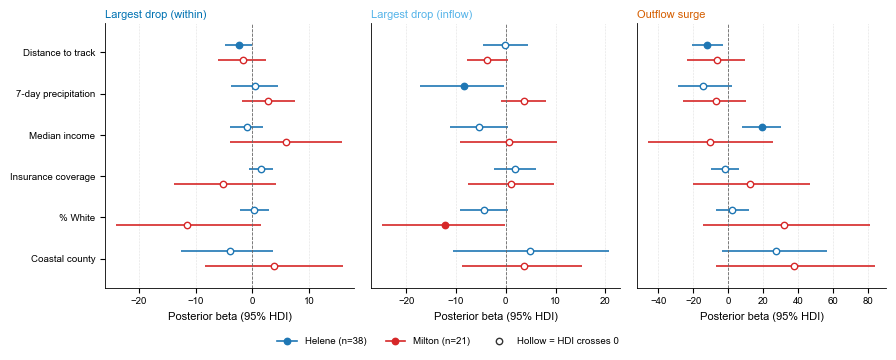

In [8]:
def plot_overlay():
    fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.5))
    y_positions = np.arange(len(DISPLAY_PREDICTORS))[::-1]
    HURR_OFFSET = {'helene': +0.18, 'milton': -0.18}

    for j, (ax, dv_lab) in enumerate(zip(axes, DV_ORDER)):
        for hkey in ['helene', 'milton']:
            summ = get_summary(hkey, dv_lab)
            color = HURR_COLOR[hkey]
            offset = HURR_OFFSET[hkey]

            for k, var in enumerate(DISPLAY_PREDICTORS):
                mean = summ.loc[var, 'mean']
                lo, hi = summ.loc[var, 'hdi_2.5%'], summ.loc[var, 'hdi_97.5%']
                sig = (lo > 0) or (hi < 0)

                y = y_positions[k] + offset
                ax.hlines(y, lo, hi, colors=color, linewidth=1.2, zorder=2)
                ax.plot(mean, y, marker='o', markersize=4.6,
                        markerfacecolor=color if sig else 'white',
                        markeredgecolor=color, markeredgewidth=1.0, zorder=3)

        ax.axvline(0, color='#666', linewidth=0.6, linestyle='--')
        ax.set_yticks(y_positions)
        if j == 0:
            ax.set_yticklabels([PREDICTOR_LABEL[v] for v in DISPLAY_PREDICTORS])
        else:
            ax.set_yticklabels([''] * len(DISPLAY_PREDICTORS))
            ax.tick_params(axis='y', length=0)
        ax.set_ylim(-0.7, len(DISPLAY_PREDICTORS) - 0.3)
        ax.set_xlabel('Posterior beta (95% HDI)')
        ax.set_title(DV_SHORT[dv_lab], loc='left', fontsize=8, color=DV_COLOR[dv_lab], pad=4)
        ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.7)

    # Shared legend
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='-', color=HURR_COLOR['helene'],
               markerfacecolor=HURR_COLOR['helene'], markeredgecolor=HURR_COLOR['helene'],
               markersize=4.6, linewidth=1.2, label='Helene (n=38)'),
        Line2D([0], [0], marker='o', linestyle='-', color=HURR_COLOR['milton'],
               markerfacecolor=HURR_COLOR['milton'], markeredgecolor=HURR_COLOR['milton'],
               markersize=4.6, linewidth=1.2, label='Milton (n=21)'),
        Line2D([0], [0], marker='o', linestyle='none', color='#333',
               markerfacecolor='white', markeredgecolor='#333',
               markersize=4.6, linewidth=1.0, label='Hollow = HDI crosses 0'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', frameon=False,
               fontsize=7, ncol=3, bbox_to_anchor=(0.5, -0.02))

    fig.tight_layout(rect=[0, 0.04, 1, 1])
    save_panel(fig, 'figure5_supp_bayesian_indep_overlay')
    plt.show()

plot_overlay()

## Bayesian vs OLS per storm — how much do the priors shrink Milton?

For each storm × DV, overlay the per-storm OLS coefficient (grey squares) with the per-storm Bayesian posterior (coloured circles). This shows where the N(0, 1) prior is doing its regularisation work, particularly for Milton where OLS has df_resid ≈ 14 with 6 predictors.

Expected pattern:
- Helene (n = 38): Bayesian and OLS should be very close (priors are dominated by data)
- Milton (n = 21): Bayesian coefficients should be modestly *shrunken toward zero* relative to OLS, especially for OLS estimates with wide CIs


=== OLS alignment sanity check: Milton × Outflow surge × median_household_income ===
  This notebook (10-predictor):  coef = -17.71   p = 0.383
  Should match figure5 S1:       coef = -16.31    p = 0.383
  (Earlier 6-predictor version:  coef =  +9.68    p = 0.272 — sign was flipped)

  saved → results/npj_figures/figure5_supp_bayesian_indep_vs_ols.pdf
  saved → results/npj_figures/figure5_supp_bayesian_indep_vs_ols.png


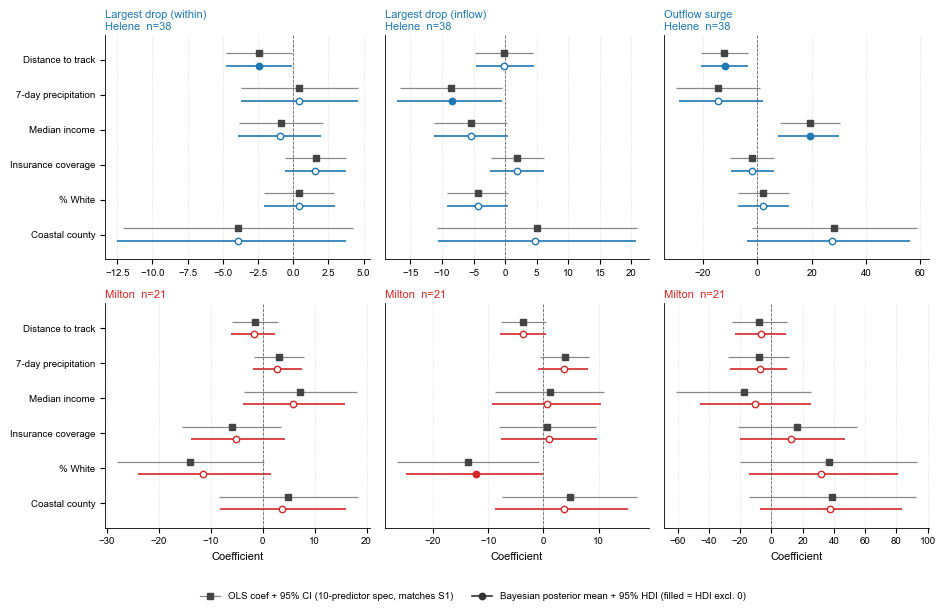

In [9]:
def fit_ols_per_storm(hkey, dv_col):
    """Per-storm OLS with the SAME 10-predictor spec as the Bayesian fit and as
    figure5_socioeconomic_drivers.ipynb supplement S1's PER_HURRICANE_FEATURES.

    Note: predictors are already z-scored globally in POOL_Z, so coefficients are
    on the standardised scale (matches the Bayesian posterior scale).
    """
    sub = POOL_Z[POOL_Z['hurricane'] == hkey].dropna(subset=[dv_col] + MODEL_FEATURES).copy()
    X = sm.add_constant(sub[MODEL_FEATURES])
    return sm.OLS(sub[dv_col], X).fit()


def plot_vs_ols():
    fig, axes = plt.subplots(2, 3, figsize=(9.5, 6.0))
    y_positions = np.arange(len(DISPLAY_PREDICTORS))[::-1]

    for i, hkey in enumerate(['helene', 'milton']):
        for j, dv_lab in enumerate(DV_ORDER):
            dv_col = DV_TO_COL[dv_lab]
            ax = axes[i, j]
            color = HURR_COLOR[hkey]

            ols_fit = fit_ols_per_storm(hkey, dv_col)
            ols_ci = ols_fit.conf_int()
            summ_b = get_summary(hkey, dv_lab)

            for k, var in enumerate(DISPLAY_PREDICTORS):
                # OLS (offset up)
                coef_o = ols_fit.params[var]
                lo_o, hi_o = ols_ci.loc[var]
                ax.hlines(y_positions[k] + 0.18, lo_o, hi_o, colors='#888', linewidth=0.9, zorder=2)
                ax.plot(coef_o, y_positions[k] + 0.18, marker='s', markersize=4, color='#444', zorder=3)

                # Bayes (offset down)
                mean_b = summ_b.loc[var, 'mean']
                lo_b = summ_b.loc[var, 'hdi_2.5%']
                hi_b = summ_b.loc[var, 'hdi_97.5%']
                sig = (lo_b > 0) or (hi_b < 0)
                ax.hlines(y_positions[k] - 0.18, lo_b, hi_b, colors=color, linewidth=1.2, zorder=2)
                ax.plot(mean_b, y_positions[k] - 0.18, marker='o', markersize=4.6,
                        markerfacecolor=color if sig else 'white',
                        markeredgecolor=color, markeredgewidth=1.0, zorder=3)

            ax.axvline(0, color='#666', linewidth=0.6, linestyle='--')
            ax.set_yticks(y_positions)
            if j == 0:
                ax.set_yticklabels([PREDICTOR_LABEL[v] for v in DISPLAY_PREDICTORS])
            else:
                ax.set_yticklabels([''] * len(DISPLAY_PREDICTORS))
                ax.tick_params(axis='y', length=0)
            ax.set_ylim(-0.7, len(DISPLAY_PREDICTORS) - 0.3)

            if i == 1:
                ax.set_xlabel('Coefficient')

            n = fits[(hkey, dv_lab)]['n']
            title = f'{DV_SHORT[dv_lab]}\n{hkey.title()}  n={n}' if i == 0 else f'{hkey.title()}  n={n}'
            ax.set_title(title, loc='left', fontsize=8, color=color, pad=4)
            ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.7)

    legend_handles = [
        Line2D([0], [0], marker='s', linestyle='-', color='#888',
               markerfacecolor='#444', markeredgecolor='#444',
               markersize=4, linewidth=0.9, label='OLS coef + 95% CI (10-predictor spec, matches S1)'),
        Line2D([0], [0], marker='o', linestyle='-', color='#333',
               markerfacecolor='#333', markeredgecolor='#333',
               markersize=4.6, linewidth=1.2, label='Bayesian posterior mean + 95% HDI (filled = HDI excl. 0)'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', frameon=False,
               fontsize=7, ncol=2, bbox_to_anchor=(0.5, -0.02))

    fig.tight_layout(rect=[0, 0.04, 1, 1])
    save_panel(fig, 'figure5_supp_bayesian_indep_vs_ols')
    plt.show()


# Sanity check: print the OLS coefficients for the predictor that previously didn't
# match S1, to confirm the alignment is now correct.
print('=== OLS alignment sanity check: Milton × Outflow surge × median_household_income ===')
fit_check = fit_ols_per_storm('milton', 'largest_increase_outflow')
c = fit_check.params['median_household_income']
p = fit_check.pvalues['median_household_income']
print(f'  This notebook (10-predictor):  coef = {c:+.2f}   p = {p:.3f}')
print(f'  Should match figure5 S1:       coef = -16.31    p = 0.383')
print(f'  (Earlier 6-predictor version:  coef =  +9.68    p = 0.272 — sign was flipped)')
print()

plot_vs_ols()

## Caption draft (for the assembled supplementary independent-Bayesian figure)

**Fig. S? | Independent-per-storm Bayesian regression of socioeconomic and hazard predictors on hurricane mobility disruption.** Six independent Bayesian regressions (3 DVs × 2 storms) were fit using the same 10-predictor specification as `figure5_socioeconomic_drivers.ipynb` supplement S1: 9 z-scored continuous predictors (`median_household_income`, `pct_no_vehicle`, `pct_white`, `nchs_code`, `total_population`, `pop_density`, `dist_to_track_mi`, `insurance_coverage_pct`, `precip_total_7day`) + 1 binary (`is_coastal`). Weakly informative priors scaled to the pooled-sample DV standard deviation: `β_k ~ Normal(0, 2.5 σ_y)` on standardised slopes, `α ~ Normal(0, 10 σ_y)` on intercepts, `σ_y ~ HalfNormal(0, σ_y^pooled)` on residual sd (Gelman default for weakly informative regression priors). 4 chains × 2000 draws after 1500 tuning, target_accept = 0.95. Forest plots display only the 6 highlighted predictors; the 4 nuisance controls (`pct_no_vehicle`, `nchs_code`, `total_population`, `pop_density`) are fitted to absorb confounding variance but not shown.

**(a, per-storm forest)** Posterior means + 95% HDIs for each predictor, separately by storm (top: Helene; bottom: Milton). Filled markers indicate HDI excludes zero. Same 2×3 layout as supplement S1 (OLS) for direct comparison.

**(b, overlay)** Helene (blue) and Milton (red) posteriors plotted on the same axes per predictor, one subplot per DV. Visual non-overlap of HDIs is the criterion for "the storms genuinely differ." Where HDIs overlap, the data is consistent with both storms having similar effects.

**(c, Bayesian vs OLS)** Per-storm OLS coefficient (grey squares + 95% CI, **same 10-predictor spec as S1**) overlaid with per-storm Bayesian posterior (colour-coded circles + 95% HDI). Helene rows show Bayesian ≈ OLS (priors dominated by data at n = 38). Milton rows show modest Bayesian shrinkage toward zero, as expected for n = 21 with priors providing soft regularisation. The OLS coefficients in this panel are *identical* to those in S1 by construction.

**Why independent and not hierarchical**. A hierarchical model with random intercept and slopes by hurricane (see `figure5_supp_bayesian_hierarchical.ipynb`) is the standard approach for borrowing strength across groups. With only J = 2 hurricane groups, however, the between-storm variance σ_k cannot be estimated from data — the posterior σ_k is essentially the prior. Tight σ_k priors over-shrink storm-specific slopes toward each other (artefactual agreement); loose σ_k priors produce Neal's-funnel divergences during NUTS sampling. Independent per-storm models avoid this trap entirely, at the cost of formal cross-storm pooling — which is not informative at J = 2 anyway.

**Files written:**
- `results/npj_figures/figure5_supp_bayesian_indep_per_storm.{pdf,png}`
- `results/npj_figures/figure5_supp_bayesian_indep_overlay.{pdf,png}`
- `results/npj_figures/figure5_supp_bayesian_indep_vs_ols.{pdf,png}`